# Agents vs club
This notebook answers: **Which agents deal with each club?**
- Club is defined by `club_name` from `team_details`.
- Agent is `player_agent_name` from `player_profiles`.
- We show a co-occurrence matrix and a top-30 agent-club pairs figure.

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = '../PreProcessdData'
player_profiles = pd.read_csv(f'{DATA_DIR}/player_profiles/player_profiles.csv')
team_details = pd.read_csv(f'{DATA_DIR}/team_details/team_details.csv')

agent_col = 'player_agent_name'
competition_col = 'competition_name'
club_name_col = 'club_name'

profiles = player_profiles[['current_club_id', agent_col]].dropna()
teams = team_details[['club_id', 'club_name', 'competition_name']].dropna()

merged = profiles.merge(teams, left_on='current_club_id', right_on='club_id', how='inner')
merged[agent_col] = merged[agent_col].astype(str).str.strip()
merged[club_name_col] = merged[club_name_col].astype(str).str.strip()
merged[competition_col] = merged[competition_col].astype(str).str.strip()
merged = merged[(merged[agent_col] != '') & (merged[club_name_col] != '') & (merged[competition_col] != '')]

print('Merged rows:', len(merged))
display(merged.head())

co_matrix = pd.crosstab(merged[agent_col], merged[club_name_col])
print('Co-occurrence matrix shape:', co_matrix.shape)

Merged rows: 22943


,current_club_id,player_agent_name,club_id,club_name,competition_name
0,14554,OLLER GROUP,14554,Club Atlético Tucumán (14554),Torneo Clausura
1,103657,Prodigy Players,103657,Carolina Core FC (103657),MLS Next Pro
2,78435,EL C1EL0,78435,Charlotte FC (78435),Major League Soccer
3,78435,Agent is known - Player under 18,78435,Charlotte FC (78435),Major League Soccer
4,20518,DK SPORT CONSEIL,20518,US Chantilly (20518),Championnat National 2 - Groupe B


Co-occurrence matrix shape: (3124, 1599)


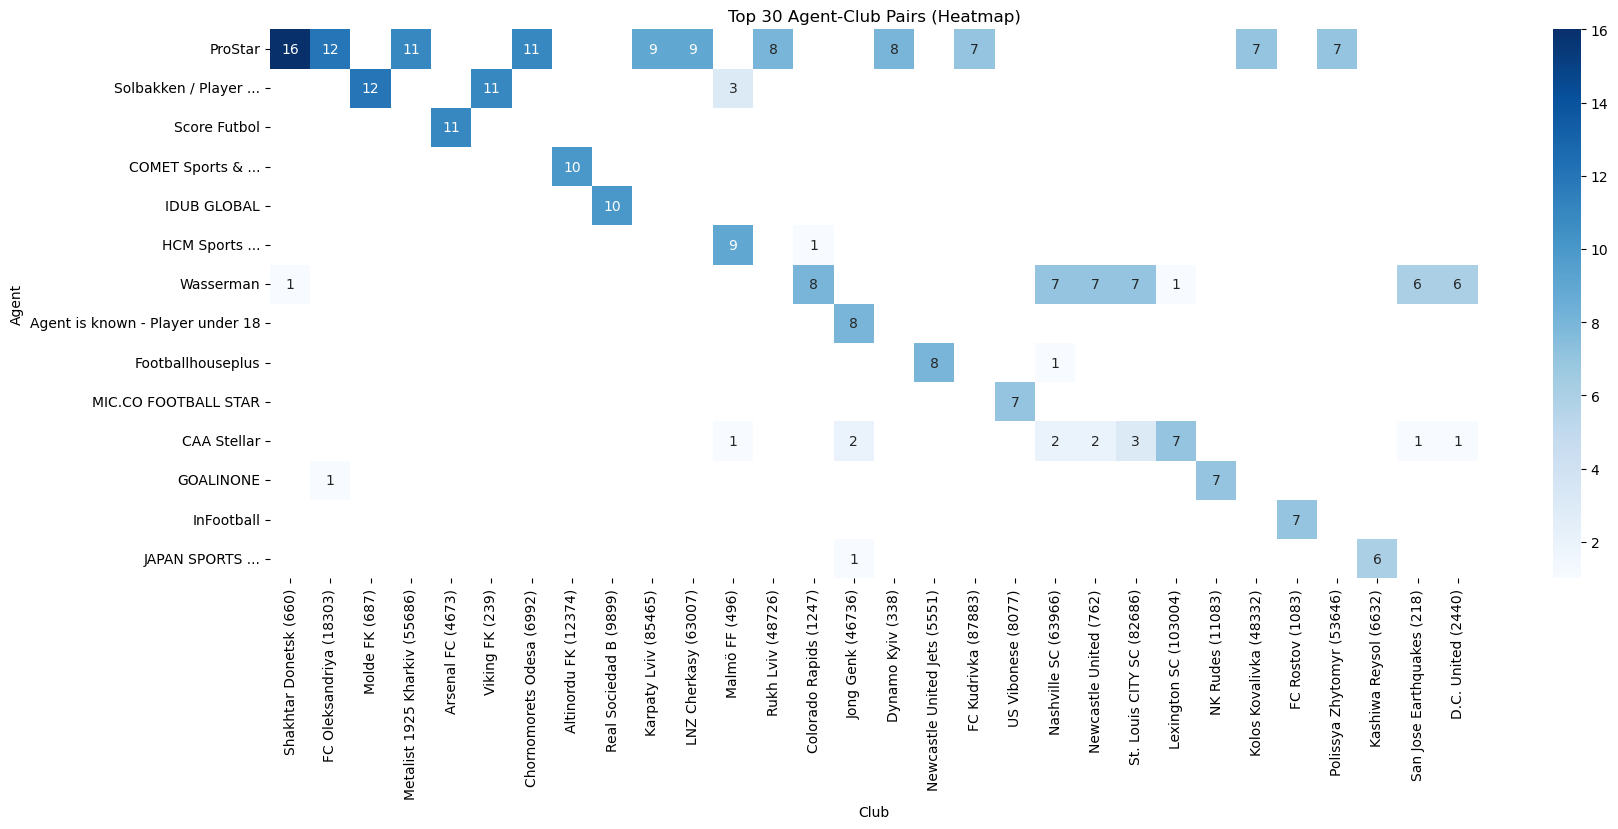

In [33]:
# Top 30 agent-club pairs (overall) as heatmap using full counts for selected axes.
top30_pairs = (
    merged.groupby([agent_col, club_name_col])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(30)
    .copy()
 )

if top30_pairs.empty:
    print('No data to plot for top 30 pairs.')
else:
    top_agents = top30_pairs[agent_col].unique().tolist()
    top_clubs = top30_pairs[club_name_col].unique().tolist()
    filtered = merged[merged[agent_col].isin(top_agents) & merged[club_name_col].isin(top_clubs)]
    heat = pd.crosstab(filtered[agent_col], filtered[club_name_col]).reindex(index=top_agents, columns=top_clubs).fillna(0)
    heat = heat.loc[(heat.sum(axis=1) > 0), (heat.sum(axis=0) > 0)]
    if heat.empty:
        print('Heatmap is empty after filtering nonzero rows/columns.')
    else:
        fig_w = max(8, min(20, heat.shape[1] * 0.6))
        fig_h = max(6, min(20, heat.shape[0] * 0.6))
        plt.figure(figsize=(fig_w, fig_h))
        sns.heatmap(heat, cmap='Blues', annot=True, fmt='.0f', mask=heat == 0)
        plt.title('Top 30 Agent-Club Pairs (Heatmap)')
        plt.xlabel('Club')
        plt.ylabel('Agent')
        plt.tight_layout()
        plt.show()

Premier League rows: 511


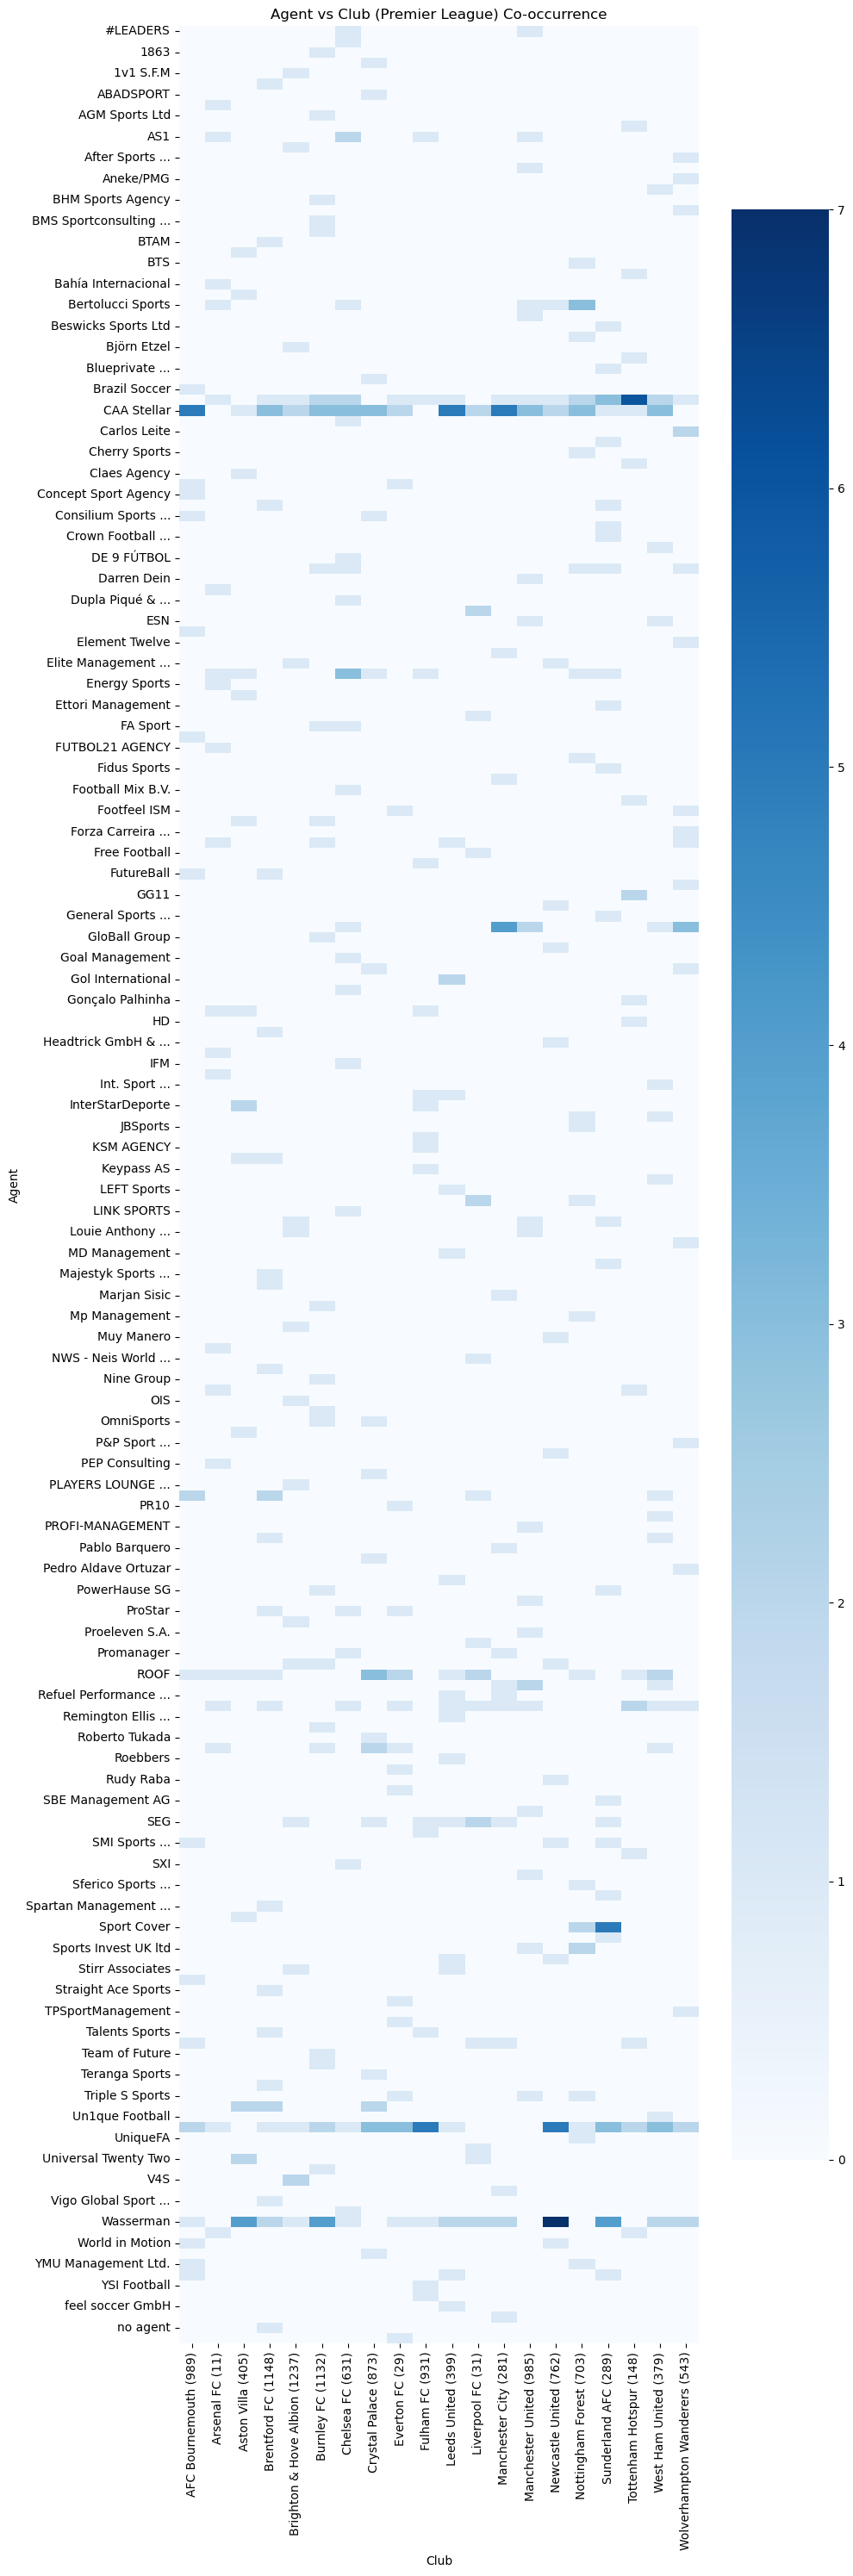

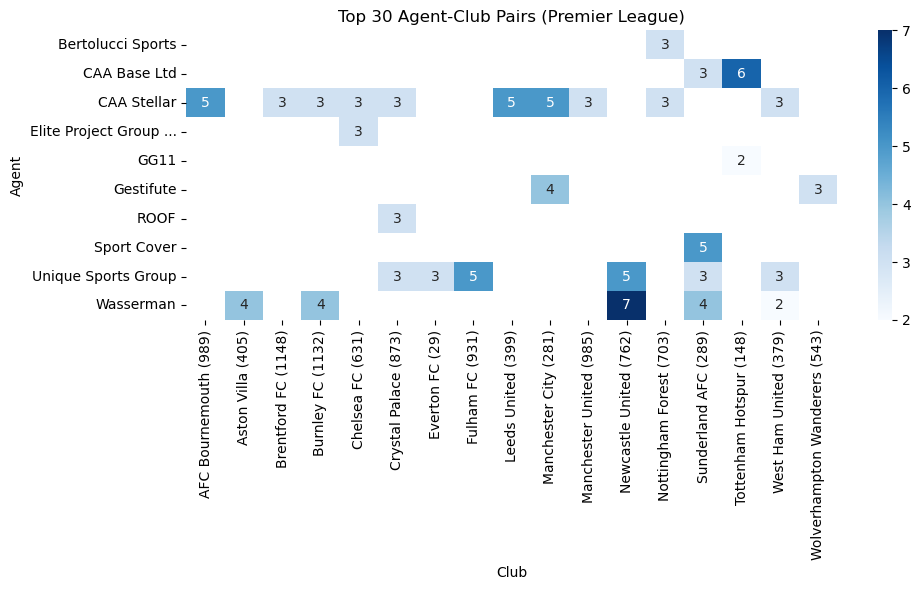

In [34]:
# Premier League only: full co-occurrence heatmap and top-30 heatmap.
target_competition = 'Premier League'
pl_merged = merged[merged[competition_col] == target_competition]
print('Premier League rows:', len(pl_merged))

pl_matrix = pd.crosstab(pl_merged[agent_col], pl_merged[club_name_col])
if pl_matrix.size == 0:
    print('No data to plot for Premier League co-occurrence matrix.')
else:
    fig_w = max(10, min(30, pl_matrix.shape[1] * 0.4))
    fig_h = max(8, min(30, pl_matrix.shape[0] * 0.3))
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(pl_matrix, cmap='Blues')
    plt.title('Agent vs Club (Premier League) Co-occurrence')
    plt.xlabel('Club')
    plt.ylabel('Agent')
    plt.tight_layout()
    plt.show()

pl_pair_counts = (
    pl_merged.groupby([agent_col, club_name_col])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(30)
    .copy()
 )

if pl_pair_counts.empty:
    print('No data to plot for top 30 pairs in Premier League.')
else:
    pl_heat = pl_pair_counts.pivot(index=agent_col, columns=club_name_col, values='count').fillna(0)
    pl_heat = pl_heat.loc[(pl_heat.sum(axis=1) > 0), (pl_heat.sum(axis=0) > 0)]
    if pl_heat.empty:
        print('Top-30 Premier League heatmap is empty after filtering nonzero rows/columns.')
    else:
        fig_w = max(8, min(20, pl_heat.shape[1] * 0.6))
        fig_h = max(6, min(20, pl_heat.shape[0] * 0.6))
        plt.figure(figsize=(fig_w, fig_h))
        sns.heatmap(pl_heat, cmap='Blues', annot=True, fmt='.0f', mask=pl_heat == 0)
        plt.title('Top 30 Agent-Club Pairs (Premier League)')
        plt.xlabel('Club')
        plt.ylabel('Agent')
        plt.tight_layout()
        plt.show()

LaLiga League rows: 446


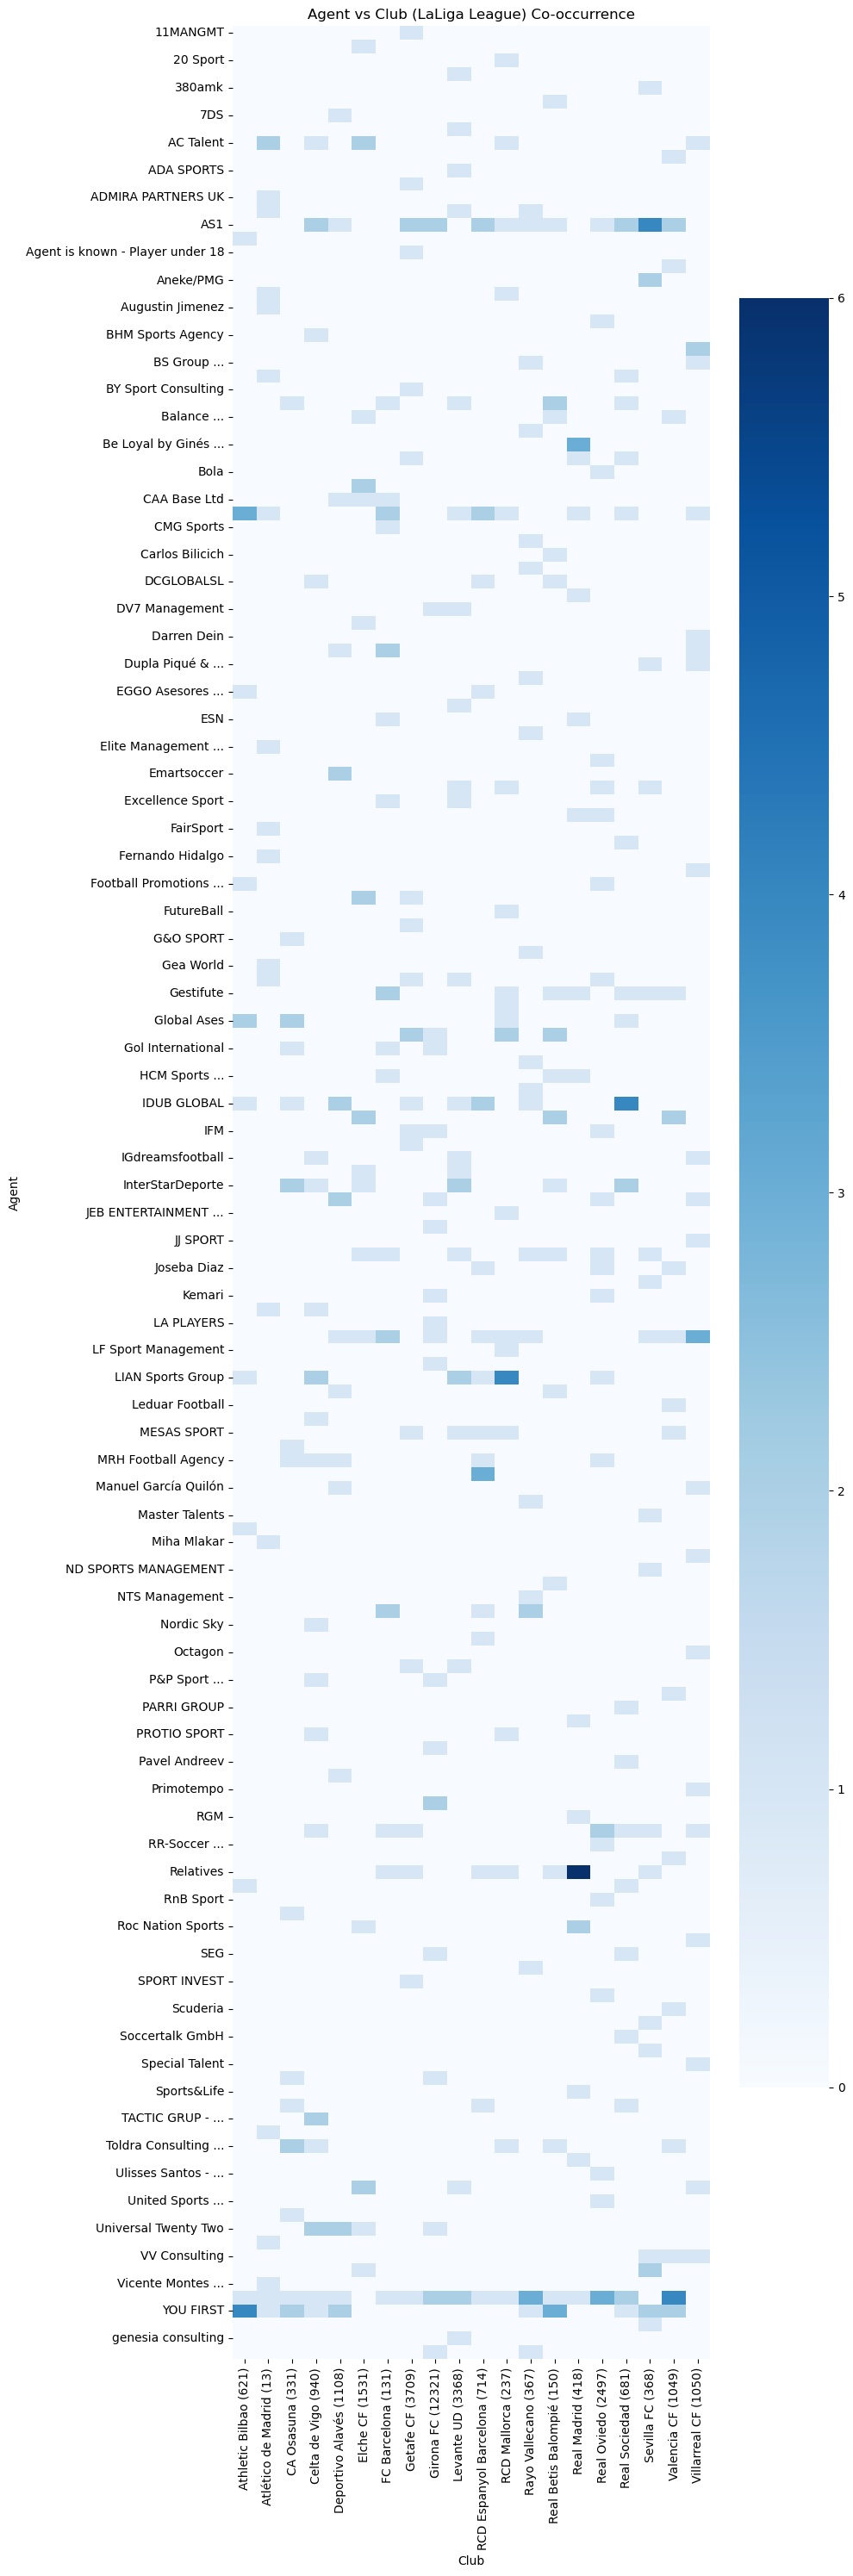

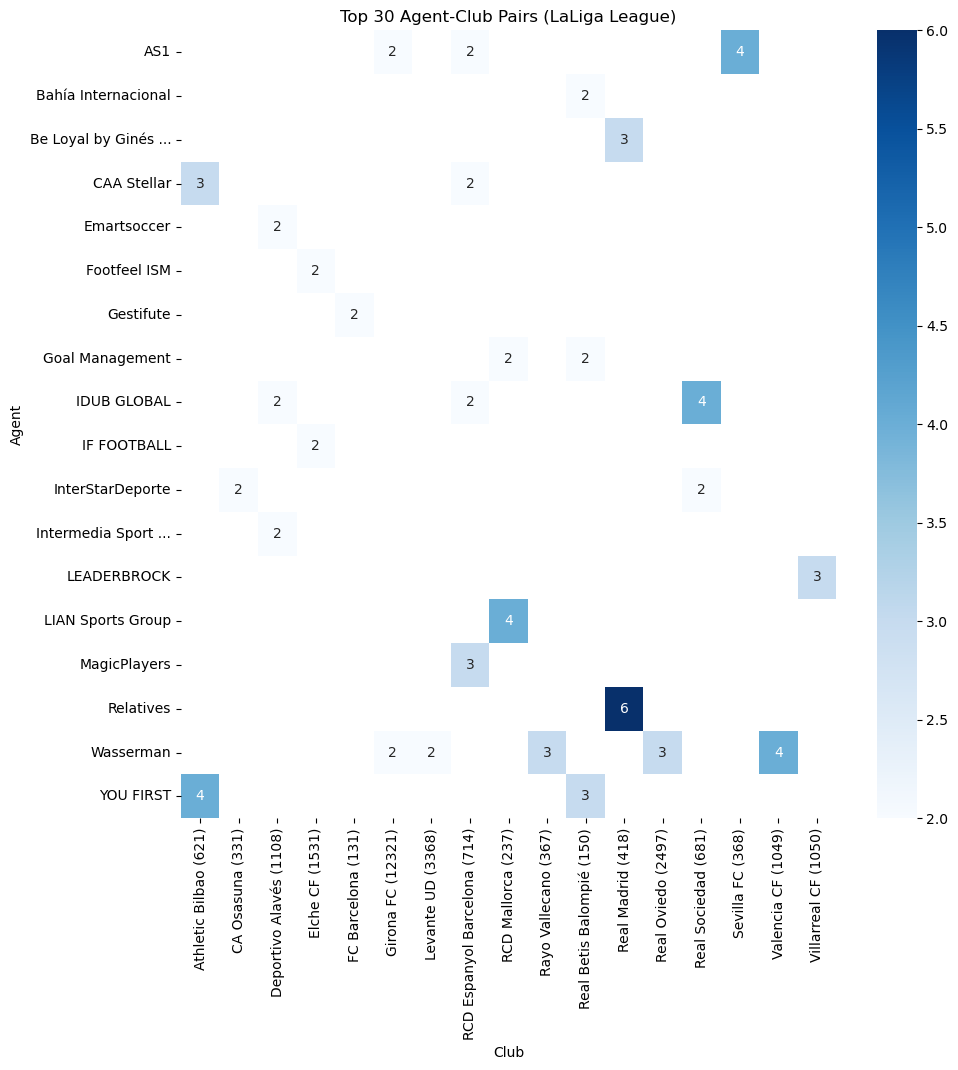

In [35]:
target_competition = 'LaLiga'
ll_merged = merged[merged[competition_col] == target_competition]
print('LaLiga League rows:', len(ll_merged))

ll_matrix = pd.crosstab(ll_merged[agent_col], ll_merged[club_name_col])
if ll_matrix.size == 0:
    print('No data to plot for LaLiga League co-occurrence matrix.')
else:
    fig_w = max(10, min(30, ll_matrix.shape[1] * 0.4))
    fig_h = max(8, min(30, ll_matrix.shape[0] * 0.3))
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(ll_matrix, cmap='Blues')
    plt.title('Agent vs Club (LaLiga League) Co-occurrence')
    plt.xlabel('Club')
    plt.ylabel('Agent')
    plt.tight_layout()
    plt.show()

ll_pair_counts = (
    ll_merged.groupby([agent_col, club_name_col])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(30)
    .copy()
 )

if ll_pair_counts.empty:
    print('No data to plot for top 30 pairs in LaLiga League.')
else:
    ll_heat = ll_pair_counts.pivot(index=agent_col, columns=club_name_col, values='count').fillna(0)
    ll_heat = ll_heat.loc[(ll_heat.sum(axis=1) > 0), (ll_heat.sum(axis=0) > 0)]
    if ll_heat.empty:
        print('Top-30 LaLiga League heatmap is empty after filtering nonzero rows/columns.')
    else:
        fig_w = max(8, min(20, ll_heat.shape[1] * 0.6))
        fig_h = max(6, min(20, ll_heat.shape[0] * 0.6))
        plt.figure(figsize=(fig_w, fig_h))
        sns.heatmap(ll_heat, cmap='Blues', annot=True, fmt='.0f', mask=ll_heat == 0)
        plt.title('Top 30 Agent-Club Pairs (LaLiga League)')
        plt.xlabel('Club')
        plt.ylabel('Agent')
        plt.tight_layout()
        plt.show()